# 📊 SaaS Business Intelligence — End-to-End Data Analysis Portfolio
### Tools: Python · Pandas · Matplotlib · Plotly
**Dataset:** `saas_customers.csv` — 2,010 rows × 22 columns  
**Domain:** B2B SaaS — Customer Revenue, Churn, Health & Acquisition Analytics

---
## 📋 Table of Contents
1. [Environment Setup & Data Loading](#1)
2. [Basic Exploration](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Feature Engineering](#4)
5. [Intermediate Analysis — GroupBy, Pivot, Aggregations](#5)
6. [Advanced Analysis — Cohort, Churn, LTV, MRR Waterfall](#6)
7. [Matplotlib Visualizations](#7)
8. [Plotly Interactive Dashboard](#8)
9. [Key Business Insights Summary](#9)


---
## 1. Environment Setup & Data Loading <a id='1'></a>

In [33]:
# ── Install / upgrade libraries if needed ──────────────────────────────────
# !pip install pandas numpy matplotlib seaborn plotly --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


In [34]:
# ── Load raw CSV ───────────────────────────────────────────────────────────
df_raw = pd.read_csv('saas_customers.csv')

print(f"Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")


Shape: (2010, 22)
Rows: 2,010  |  Columns: 22


---
## 2. Basic Exploration <a id='2'></a>

In [3]:
# First look at the data
df_raw.head(10)


,customer_id,signup_date,plan,industry,region,mrr,acv,seats,contract_type,churn,churn_date,nps_score,health_score,feature_adoption_pct,monthly_logins,support_tickets_30d,api_calls_30d,expansion_mrr,sales_rep,cs_tier,payment_method,acquisition_channel
0,CUST-01197,10-27-2022,Starter,HR Tech,Europe,28.66,292.33,3,Monthly,1,2023-05-11,1.00,28.17,26.50,7.70,26,209,0.00,David Kim,Bronze,Bank Transfer,Organic Search
1,CUST-00527,05-28-2023,Starter,EdTech,Europe,26.43,317.16,4,Annual,0,NaN,26.00,40.27,38.70,4.20,12,7809,0.00,Bob Martinez,Bronze,PayPal,Partner
2,CUST-00394,2021-05-24,Starter,E-Commerce,North America,29.62,302.12,4,Monthly,0,NaN,48.00,35.52,47.80,5.90,29,1676,0.00,David Kim,Bronze,Credit Card,Product Hunt
3,CUST-01405,29/06/2023,Growth,Real Estate,Middle East & Africa,96.01,979.30,9,Monthly,0,NaN,-61.00,23.93,17.50,7.70,19,8386,0.00,Alice Chen,Bronze,Credit Card,NaN
4,CUST-00434,10-29-2021,Growth,HealthTech,North America,95.01,969.10,10,Monthly,0,NaN,-55.00,41.85,39.20,10.60,7,3215,0.00,Alice Chen,Silver,Credit Card,Paid Search
5,CUST-00577,10/09/2022,Business,e-commerce,Asia-Pacific,305.46,8064.14,49,Multi-Year,0,NaN,NaN,0.00,43.20,0.00,2,941,143.10,Eva Rossi,Silver,Credit Card,Referral
6,CUST-01212,2023-11-16,Free,HR Tech,North America,0,0.00,1,Monthly,0,NaN,-10.00,26.74,39.40,1.30,23,272,0.00,NaN,Bronze,Credit Card,Referral
7,CUST-00430,04-27-2022,Growth,Logistics,Europe,97.96,999.19,12,Monthly,0,NaN,-91.00,41.88,79.20,10.90,20,36869,0.00,David Kim,Silver,Invoice,Referral
8,CUST-00612,28/02/2021,Starter,Cybersecurity,Europe,28.62,343.44,1,Annual,1,2021-09-23,45.00,29.24,15.40,7.70,26,425,0.00,NaN,Bronze,PayPal,Social Media
9,CUST-00531,"April 13, 2021",Enterprise,E-Commerce,Europe,969.25,11631.00,335,Annual,1,2022-07-10,-67.00,19.93,32.50,1.60,22,3329,0.00,Alice Chen,Platinum,Invoice,Social Media


In [35]:
# Data types and non-null counts
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           2010 non-null   object 
 1   signup_date           2010 non-null   object 
 2   plan                  2010 non-null   object 
 3   industry              2010 non-null   object 
 4   region                2010 non-null   object 
 5   mrr                   2010 non-null   object 
 6   acv                   2010 non-null   float64
 7   seats                 2010 non-null   int64  
 8   contract_type         2010 non-null   object 
 9   churn                 2010 non-null   int64  
 10  churn_date            445 non-null    object 
 11  nps_score             1871 non-null   float64
 12  health_score          1930 non-null   float64
 13  feature_adoption_pct  2010 non-null   float64
 14  monthly_logins        2010 non-null   float64
 15  support_tickets_30d  

In [5]:
# Statistical summary — numeric columns
df_raw.describe(include='number').T.style.background_gradient(cmap='Blues', axis=1)


,count,mean,std,min,25%,50%,75%,max
acv,2010.000000,2449.859015,5513.360793,0.000000,264.080000,346.140000,1251.330000,28811.380000
seats,2010.000000,27.122388,77.931770,1.000000,2.000000,4.000000,13.000000,493.000000
churn,2010.000000,0.221393,0.415288,0.000000,0.000000,0.000000,0.000000,1.000000
nps_score,1871.000000,-0.548370,57.750826,-100.000000,-52.000000,1.000000,49.000000,100.000000
health_score,1930.000000,39.757767,17.406847,0.000000,29.780000,40.435000,51.285000,89.900000
feature_adoption_pct,2010.000000,39.823284,20.435428,0.400000,23.800000,38.500000,53.875000,96.300000
monthly_logins,2010.000000,10.814179,9.349156,0.000000,3.300000,7.900000,16.000000,31.000000
support_tickets_30d,2010.000000,14.695522,8.997474,0.000000,7.000000,14.000000,22.000000,30.000000
api_calls_30d,2010.000000,3289.226866,8234.885888,10.000000,405.500000,1111.000000,2971.750000,158954.000000
expansion_mrr,2010.000000,7.752010,38.686776,0.000000,0.000000,0.000000,0.000000,504.870000


In [6]:
# Statistical summary — object columns
df_raw.describe(include='object').T


,count,unique,top,freq
customer_id,2010,2000,CUST-00484,2
signup_date,2010,1619,02-12-2022,4
plan,2010,5,Starter,578
industry,2010,30,LegalTech,217
region,2010,10,North America,788
mrr,2010,1248,0,490
contract_type,2010,3,Monthly,1153
churn_date,445,382,2022-07-10,3
sales_rep,1302,7,Carol Singh,286
cs_tier,2010,4,Bronze,1306


In [7]:
# Missing value analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
churn_date,1565,77.86
sales_rep,708,35.22
nps_score,139,6.92
acquisition_channel,100,4.98
health_score,80,3.98
payment_method,44,2.19


In [8]:
# Value counts — categorical columns
for col in ['plan', 'contract_type', 'region', 'cs_tier', 'churn']:
    print(f"\n{'─'*40}")
    print(f"  {col.upper()}")
    print(df_raw[col].value_counts(dropna=False))



────────────────────────────────────────
  PLAN
plan
Starter       578
Free          498
Growth        465
Business      328
Enterprise    141
Name: count, dtype: int64

────────────────────────────────────────
  CONTRACT_TYPE
contract_type
Monthly       1153
Annual         719
Multi-Year     138
Name: count, dtype: int64

────────────────────────────────────────
  REGION
region
North America               788
Europe                      541
Asia-Pacific                365
Latin America               175
Middle East & Africa         91
  North America              22
  Asia-Pacific               13
  Europe                      8
  Latin America               6
  Middle East & Africa        1
Name: count, dtype: int64

────────────────────────────────────────
  CS_TIER
cs_tier
Bronze      1306
Silver       402
Gold         245
Platinum      57
Name: count, dtype: int64

────────────────────────────────────────
  CHURN
churn
0    1565
1     445
Name: count, dtype: int64


In [9]:
# Duplicate check
n_dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
print(df_raw[df_raw.duplicated(keep=False)].sort_values('customer_id').head(6))


Duplicate rows: 10
     customer_id signup_date     plan     industry         region    mrr  \
920   CUST-00165  13/02/2021     Free   E-Commerce         Europe      0   
755   CUST-00165  13/02/2021     Free   E-Commerce         Europe      0   
1463  CUST-00185  14/04/2023  Starter      HR Tech   Asia-Pacific  30.26   
471   CUST-00185  14/04/2023  Starter      HR Tech   Asia-Pacific  30.26   
877   CUST-00379  12-09-2022  Starter  Real Estate  North America  29.52   
1864  CUST-00379  12-09-2022  Starter  Real Estate  North America  29.52   

        acv  seats contract_type  churn  churn_date  nps_score  health_score  \
920    0.00      1       Monthly      0         NaN      43.00         43.66   
755    0.00      1       Monthly      0         NaN      43.00         43.66   
1463 308.65      2       Monthly      0         NaN      25.00         58.19   
471  308.65      2       Monthly      0         NaN      25.00         58.19   
877  354.24      2        Annual      1  2023-06

---
## 3. Data Cleaning & Preprocessing <a id='3'></a>

### 3.1 Remove Duplicates

In [10]:
df = df_raw.drop_duplicates(subset='customer_id', keep='first').copy()
print(f"Rows after dedup: {len(df):,}  (removed {len(df_raw) - len(df)} rows)")


Rows after dedup: 2,000  (removed 10 rows)


### 3.2 Fix Column — `industry` (inconsistent casing)

In [11]:
# Before
print("Before:", df['industry'].unique()[:8])

df['industry'] = df['industry'].str.strip().str.title()

# After
print("After: ", df['industry'].unique()[:8])
print("Unique industries:", df['industry'].nunique())


Before: ['HR Tech' 'EdTech' 'E-Commerce' 'Real Estate' 'HealthTech' 'e-commerce'
 'Logistics' 'Cybersecurity']
After:  ['Hr Tech' 'Edtech' 'E-Commerce' 'Real Estate' 'Healthtech' 'Logistics'
 'Cybersecurity' 'Fintech']
Unique industries: 10


### 3.3 Fix Column — `region` (leading/trailing whitespace)

In [12]:
# Check for whitespace issues
print("Has whitespace:", df['region'].str.startswith(' ').sum())
df['region'] = df['region'].str.strip()
print("After fix:", df['region'].str.startswith(' ').sum())
print(df['region'].value_counts())


Has whitespace: 50
After fix: 0
region
North America           809
Europe                  544
Asia-Pacific            375
Latin America           181
Middle East & Africa     91
Name: count, dtype: int64


### 3.4 Fix Column — `mrr` (mixed types: numeric + `$` strings)

In [13]:
# Inspect dirty values
print("Dtype:", df['mrr'].dtype)
print("Sample dirty:", df[df['mrr'].astype(str).str.startswith('$')]['mrr'].head())

# Clean: strip $ and cast to float
df['mrr'] = df['mrr'].astype(str).str.replace('$', '', regex=False).astype(float)
print("\nDtype after fix:", df['mrr'].dtype)
print(df['mrr'].describe())


Dtype: object
Sample dirty: 11       $27.5
195    $312.41
217     $28.13
236     $30.86
260     $99.77
Name: mrr, dtype: object

Dtype after fix: float64
count   2000.00
mean     150.51
std      254.72
min        0.00
25%       25.80
50%       30.69
75%      106.20
max     1154.34
Name: mrr, dtype: float64


### 3.5 Fix Column — `signup_date` (4 mixed date formats)

In [14]:
# Show mixed formats
print("Sample dates:")
print(df['signup_date'].sample(10, random_state=1).values)

# pandas infer_datetime_format handles most; dayfirst=False is safer default
df['signup_date'] = pd.to_datetime(df['signup_date'], infer_datetime_format=True, dayfirst=False, errors='coerce')

# Check how many parsed correctly
unparsed = df['signup_date'].isna().sum()
print(f"\nUnparsed dates: {unparsed}")
print(f"Date range: {df['signup_date'].min().date()} → {df['signup_date'].max().date()}")


Sample dates:
['November 11, 2022' '13/07/2021' '2024-01-01' 'March 22, 2023'
 '2022-03-01' '2023-06-02' 'September 18, 2023' '28/12/2022' '2021-07-05'
 'January 31, 2022']

Unparsed dates: 1529
Date range: 2021-01-03 → 2023-12-29


### 3.6 Fix Column — `churn_date` (string → datetime)

In [15]:
df['churn_date'] = pd.to_datetime(df['churn_date'], errors='coerce')
print("churn_date dtype:", df['churn_date'].dtype)
print("Non-null:", df['churn_date'].notna().sum(), "(churned customers)")


churn_date dtype: datetime64[ns]
Non-null: 443 (churned customers)


### 3.7 Handle Missing Values

In [16]:
# ── nps_score: fill with median per plan ──────────────────────────────────
df['nps_score'] = df.groupby('plan')['nps_score'].transform(
    lambda x: x.fillna(x.median())
)

# ── health_score: fill with median per plan + cs_tier combo ───────────────
df['health_score'] = df.groupby(['plan', 'cs_tier'])['health_score'].transform(
    lambda x: x.fillna(x.median())
)

# ── payment_method: fill with mode ────────────────────────────────────────
mode_payment = df['payment_method'].mode()[0]
df['payment_method'] = df['payment_method'].fillna(mode_payment)

# ── acquisition_channel: label unknown ────────────────────────────────────
df['acquisition_channel'] = df['acquisition_channel'].fillna('Unknown')

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ No remaining missing values in key columns" if df[['mrr','nps_score','health_score','payment_method']].isnull().sum().sum() == 0 else "⚠️ Still some nulls")


Missing values after cleaning:
signup_date    1529
churn_date     1557
sales_rep       704
dtype: int64

✅ No remaining missing values in key columns


### 3.8 Fix Data Types & Ordered Categoricals

In [17]:
# Ordered categorical for plan (important for groupby sort order)
plan_order = ['Free', 'Starter', 'Growth', 'Business', 'Enterprise']
df['plan'] = pd.Categorical(df['plan'], categories=plan_order, ordered=True)

# Ordered categorical for cs_tier
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
df['cs_tier'] = pd.Categorical(df['cs_tier'], categories=tier_order, ordered=True)

# Boolean churn
df['churn'] = df['churn'].astype(bool)

print(df[['plan', 'cs_tier', 'churn']].dtypes)
print(f"\nPlan ordered: {df['plan'].cat.ordered}")


plan       category
cs_tier    category
churn          bool
dtype: object

Plan ordered: True


### 3.9 Final Clean Dataset Overview

In [18]:
print(f"Final shape: {df.shape}")
df.info()


Final shape: (2000, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2009
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           2000 non-null   object        
 1   signup_date           471 non-null    datetime64[ns]
 2   plan                  2000 non-null   category      
 3   industry              2000 non-null   object        
 4   region                2000 non-null   object        
 5   mrr                   2000 non-null   float64       
 6   acv                   2000 non-null   float64       
 7   seats                 2000 non-null   int64         
 8   contract_type         2000 non-null   object        
 9   churn                 2000 non-null   bool          
 10  churn_date            443 non-null    datetime64[ns]
 11  nps_score             2000 non-null   float64       
 12  health_score          2000 non-null   float64       
 13 

---
## 4. Feature Engineering <a id='4'></a>

In [19]:
# ── Tenure (days since signup) ────────────────────────────────────────────
snapshot_date = pd.Timestamp('2024-03-31')   # analysis reference date
df['tenure_days'] = (snapshot_date - df['signup_date']).dt.days
df['tenure_months'] = (df['tenure_days'] / 30.44).round(1)

# ── Cohort month (year-month of signup) ───────────────────────────────────
df['cohort_month'] = df['signup_date'].dt.to_period('M')

# ── Days to churn ─────────────────────────────────────────────────────────
df['days_to_churn'] = (df['churn_date'] - df['signup_date']).dt.days

# ── Total MRR including expansion ─────────────────────────────────────────
df['total_mrr'] = df['mrr'] + df['expansion_mrr']

# ── ARR (Annual Recurring Revenue) ────────────────────────────────────────
df['arr'] = df['total_mrr'] * 12

# ── Revenue per seat ──────────────────────────────────────────────────────
df['mrr_per_seat'] = (df['mrr'] / df['seats']).replace([np.inf, np.nan], 0).round(2)

# ── NPS category ──────────────────────────────────────────────────────────
def nps_category(score):
    if score >= 9:   return 'Promoter'
    elif score >= 7: return 'Passive'
    else:            return 'Detractor'

# NPS is -100 to 100; normalize to 0-10 scale for categorization
df['nps_category'] = pd.cut(
    df['nps_score'],
    bins=[-101, -20, 20, 101],
    labels=['Detractor', 'Passive', 'Promoter']
)

# ── Engagement tier (qcut into 4 equal buckets) ───────────────────────────
df['engagement_tier'] = pd.qcut(
    df['feature_adoption_pct'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Champion']
)

# ── High-value flag (MRR > 75th percentile) ───────────────────────────────
mrr_75 = df['mrr'].quantile(0.75)
df['is_high_value'] = df['mrr'] > mrr_75

# ── Support intensity ─────────────────────────────────────────────────────
df['support_intensity'] = pd.cut(
    df['support_tickets_30d'],
    bins=[-1, 2, 7, 15, 100],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("New features added:")
new_cols = ['tenure_days','tenure_months','cohort_month','days_to_churn',
            'total_mrr','arr','mrr_per_seat','nps_category','engagement_tier',
            'is_high_value','support_intensity']
print(df[new_cols].dtypes.to_string())


New features added:
tenure_days            float64
tenure_months          float64
cohort_month         period[M]
days_to_churn          float64
total_mrr              float64
arr                    float64
mrr_per_seat           float64
nps_category          category
engagement_tier       category
is_high_value             bool
support_intensity     category


In [20]:
# Preview engineered features
df[['customer_id','plan','mrr','expansion_mrr','total_mrr','arr',
    'tenure_months','nps_category','engagement_tier','is_high_value']].head(10)


,customer_id,plan,mrr,expansion_mrr,total_mrr,arr,tenure_months,nps_category,engagement_tier,is_high_value
0,CUST-01197,Starter,28.66,0.00,28.66,343.92,17.10,Passive,Medium,False
1,CUST-00527,Starter,26.43,0.00,26.43,317.16,10.10,Promoter,High,False
2,CUST-00394,Starter,29.62,0.00,29.62,355.44,NaN,Promoter,High,False
3,CUST-01405,Growth,96.01,0.00,96.01,1152.12,NaN,Detractor,Low,False
4,CUST-00434,Growth,95.01,0.00,95.01,1140.12,29.00,Detractor,High,False
5,CUST-00577,Business,305.46,143.10,448.56,5382.72,NaN,Passive,High,True
6,CUST-01212,Free,0.00,0.00,0.00,0.00,NaN,Passive,High,False
7,CUST-00430,Growth,97.96,0.00,97.96,1175.52,23.10,Detractor,Champion,False
8,CUST-00612,Starter,28.62,0.00,28.62,343.44,NaN,Promoter,Low,False
9,CUST-00531,Enterprise,969.25,0.00,969.25,11631.00,NaN,Detractor,Medium,True


---
## 5. Intermediate Analysis — GroupBy, Pivot, Aggregations <a id='5'></a>

### 5.1 Revenue by Plan

In [21]:
revenue_by_plan = (
    df.groupby('plan', observed=True)
    .agg(
        customers       = ('customer_id', 'count'),
        total_mrr       = ('total_mrr', 'sum'),
        avg_mrr         = ('mrr', 'mean'),
        median_mrr      = ('mrr', 'median'),
        total_arr       = ('arr', 'sum'),
        avg_seats       = ('seats', 'mean'),
        avg_health      = ('health_score', 'mean'),
        churn_count     = ('churn', 'sum'),
    )
    .assign(
        churn_rate      = lambda x: (x['churn_count'] / x['customers'] * 100).round(2),
        mrr_share_pct   = lambda x: (x['total_mrr'] / x['total_mrr'].sum() * 100).round(2),
    )
)
revenue_by_plan.style.format({
    'total_mrr': '${:,.0f}', 'avg_mrr': '${:,.2f}', 'median_mrr': '${:,.2f}',
    'total_arr': '${:,.0f}', 'churn_rate': '{:.2f}%', 'mrr_share_pct': '{:.2f}%',
    'avg_seats': '{:.1f}', 'avg_health': '{:.1f}'
}).background_gradient(subset=['total_mrr','churn_rate'], cmap='RdYlGn_r')


,customers,total_mrr,avg_mrr,median_mrr,total_arr,avg_seats,avg_health,churn_count,churn_rate,mrr_share_pct
plan,,,,,,,,,,
Free,495,$0,$0.00,$0.00,$0,2.0,40.3,121,24.44%,0.00%
Starter,573,"$17,824",$28.98,$28.95,"$213,884",3.0,40.1,123,21.47%,5.63%
Growth,465,"$48,475",$98.98,$98.89,"$581,697",9.1,39.7,111,23.87%,15.31%
Business,326,"$102,774",$300.10,$301.01,"$1,233,291",28.9,38.3,58,17.79%,32.46%
Enterprise,141,"$147,510",$996.90,$990.17,"$1,770,120",270.0,39.6,30,21.28%,46.59%


### 5.2 Churn Rate by Region & Plan (Pivot Table)

In [22]:
churn_pivot = pd.pivot_table(
    df,
    values='churn',
    index='region',
    columns='plan',
    aggfunc=lambda x: f"{x.mean()*100:.1f}%",
    observed=True
)
print("Churn Rate (%) by Region × Plan")
churn_pivot


Churn Rate (%) by Region × Plan


plan,Free,Starter,Growth,Business,Enterprise
region,,,,,
Asia-Pacific,26.9%,17.5%,23.9%,12.3%,26.7%
Europe,20.8%,23.5%,26.8%,15.7%,18.8%
Latin America,20.5%,20.4%,20.9%,25.0%,15.4%
Middle East & Africa,30.0%,30.8%,21.4%,25.0%,80.0%
North America,25.8%,21.0%,22.9%,19.1%,16.4%


### 5.3 MRR by Acquisition Channel

In [23]:
channel_rev = (
    df[df['acquisition_channel'] != 'Unknown']
    .groupby('acquisition_channel')
    .agg(
        customers   = ('customer_id', 'count'),
        total_mrr   = ('total_mrr', 'sum'),
        avg_mrr     = ('total_mrr', 'mean'),
        churn_rate  = ('churn', 'mean'),
    )
    .sort_values('total_mrr', ascending=False)
    .assign(churn_rate = lambda x: (x['churn_rate']*100).round(2))
)
channel_rev.style.format({'total_mrr':'${:,.0f}','avg_mrr':'${:,.2f}','churn_rate':'{:.2f}%'})            .bar(subset=['total_mrr'], color='#4CAF50')


,customers,total_mrr,avg_mrr,churn_rate
acquisition_channel,,,,
Organic Search,445,"$66,569",$149.59,21.35%
Paid Search,333,"$52,573",$157.88,24.02%
Referral,241,"$41,869",$173.73,21.16%
Social Media,269,"$39,587",$147.16,24.16%
Direct,229,"$34,312",$149.83,19.21%
Email Campaign,195,"$33,185",$170.18,21.54%
Partner,118,"$21,420",$181.52,25.42%
Product Hunt,70,"$13,368",$190.97,20.00%


### 5.4 Multi-level GroupBy — Revenue by Region + Industry

In [24]:
region_industry = (
    df.groupby(['region', 'industry'])
    .agg(customers=('customer_id','count'), total_mrr=('total_mrr','sum'))
    .sort_values(['region','total_mrr'], ascending=[True, False])
)

# Top industry per region
top_industry = region_industry.groupby(level='region').apply(
    lambda g: g.nlargest(1, 'total_mrr')
).droplevel(0)

print("Top Revenue Industry per Region:")
top_industry.style.format({'total_mrr': '${:,.0f}'})


Top Revenue Industry per Region:


,,customers,total_mrr
region,industry,,
Asia-Pacific,E-Commerce,38,"$9,338"
Europe,Edtech,51,"$11,422"
Latin America,Hr Tech,24,"$4,705"
Middle East & Africa,Martech,12,"$2,596"
North America,Logistics,82,"$19,828"


### 5.5 Transform — Rank customers within their plan by MRR

In [25]:
df['mrr_rank_in_plan'] = df.groupby('plan', observed=True)['mrr']                         .rank(method='dense', ascending=False).astype(int)

# Show top 3 per plan
df.sort_values(['plan','mrr_rank_in_plan'])   .groupby('plan', observed=True)   .head(3)[['customer_id','plan','mrr','mrr_rank_in_plan','region','industry']]


,customer_id,plan,mrr,mrr_rank_in_plan,region,industry
6,CUST-01212,Free,0.00,1,North America,Hr Tech
14,CUST-01474,Free,0.00,1,North America,Fintech
15,CUST-00711,Free,0.00,1,North America,Healthtech
663,CUST-00082,Starter,33.63,1,North America,Logistics
1945,CUST-01298,Starter,33.33,2,Asia-Pacific,Martech
827,CUST-01274,Starter,33.28,3,North America,Martech
1613,CUST-01781,Growth,118.43,1,Middle East & Africa,Fintech
1054,CUST-00537,Growth,114.53,2,North America,Hr Tech
859,CUST-00635,Growth,112.66,3,North America,Fintech
805,CUST-01331,Business,335.28,1,North America,Legaltech


### 5.6 Apply + Custom Function — Customer Lifetime Value (simple LTV)

In [26]:
# LTV = (MRR / churn_rate_estimate) — using plan-level churn rate
plan_churn_rates = df.groupby('plan', observed=True)['churn'].mean().rename('plan_churn_rate')
df = df.merge(plan_churn_rates, on='plan', how='left')

# LTV = avg monthly revenue / monthly churn rate
df['estimated_ltv'] = df.apply(
    lambda row: round(row['total_mrr'] / row['plan_churn_rate'], 2)
                if row['plan_churn_rate'] > 0 else row['total_mrr'] * 36,
    axis=1
)

print("LTV by Plan:")
df.groupby('plan', observed=True)['estimated_ltv']   .agg(['mean','median','max'])   .style.format('${:,.0f}')


LTV by Plan:


,mean,median,max
plan,,,
Free,$0,$0,$0
Starter,$145,$137,$226
Growth,$437,$419,$670
Business,"$1,772","$1,706","$2,616"
Enterprise,"$4,917","$4,755","$7,287"


### 5.7 String Operations — Sales Rep Performance

In [27]:
rep_perf = (
    df[df['sales_rep'] != 'N/A']
    .groupby('sales_rep')
    .agg(
        accounts    = ('customer_id', 'count'),
        total_mrr   = ('total_mrr', 'sum'),
        avg_health  = ('health_score', 'mean'),
        churn_rate  = ('churn', 'mean'),
        avg_nps     = ('nps_score', 'mean'),
    )
    .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
    .sort_values('total_mrr', ascending=False)
)

# Extract first name using string ops
rep_perf.index = rep_perf.index.str.split().str[0]
rep_perf.style.format({
    'total_mrr': '${:,.0f}', 'avg_health': '{:.1f}',
    'churn_rate': '{:.1f}%', 'avg_nps': '{:.1f}'
}).highlight_max(subset=['total_mrr','avg_nps'], color='#c8f7c5')   .highlight_min(subset=['churn_rate'], color='#c8f7c5')


,accounts,total_mrr,avg_health,churn_rate,avg_nps
sales_rep,,,,,
David,266,"$56,083",39.6,24.1%,-2.7
Carol,285,"$48,924",39.8,20.7%,1.0
Alice,273,"$44,327",40.0,21.6%,-0.1
Bob,265,"$42,418",39.3,17.7%,-3.0
Frank,66,"$39,365",40.2,16.7%,2.8
Grace,71,"$38,021",39.1,23.9%,-4.7
Eva,70,"$34,292",39.4,20.0%,-8.4


---
## 6. Advanced Analysis — Cohort, Churn, LTV, MRR Waterfall <a id='6'></a>

### 6.1 Monthly Cohort Retention Analysis

In [28]:
# Build cohort table
df['cohort_str'] = df['cohort_month'].astype(str)

cohort_data = df.groupby('cohort_str').agg(
    cohort_size = ('customer_id', 'count'),
    churned     = ('churn', 'sum'),
).assign(retained=lambda x: x['cohort_size'] - x['churned'])

cohort_data['retention_rate'] = (cohort_data['retained'] / cohort_data['cohort_size'] * 100).round(1)
cohort_data['churn_rate']     = (cohort_data['churned']  / cohort_data['cohort_size'] * 100).round(1)

# Show last 12 cohorts
cohort_data.tail(12).style.format({
    'retention_rate': '{:.1f}%', 'churn_rate': '{:.1f}%'
}).background_gradient(subset='retention_rate', cmap='RdYlGn')


,cohort_size,churned,retained,retention_rate,churn_rate
cohort_str,,,,,
2023-02,9,4,5,55.6%,44.4%
2023-03,9,2,7,77.8%,22.2%
2023-04,17,1,16,94.1%,5.9%
2023-05,16,2,14,87.5%,12.5%
2023-06,18,6,12,66.7%,33.3%
2023-07,11,3,8,72.7%,27.3%
2023-08,13,1,12,92.3%,7.7%
2023-09,13,3,10,76.9%,23.1%
2023-10,11,5,6,54.5%,45.5%


### 6.2 MRR Waterfall — New / Expansion / Churned / Net

In [29]:
# Monthly MRR movements
df['signup_month'] = df['signup_date'].dt.to_period('M').astype(str)
df['churn_month']  = df['churn_date'].dt.to_period('M').astype(str)

new_mrr = df.groupby('signup_month')['mrr'].sum().rename('new_mrr')
exp_mrr = df[df['expansion_mrr']>0].groupby('signup_month')['expansion_mrr'].sum().rename('expansion_mrr')
chu_mrr = df[df['churn']==True].groupby('churn_month')['mrr'].sum().rename('churned_mrr')

waterfall = pd.concat([new_mrr, exp_mrr, chu_mrr], axis=1).fillna(0)
waterfall = waterfall[waterfall.index >= '2021-01'].tail(24)
waterfall['net_new_mrr'] = waterfall['new_mrr'] + waterfall['expansion_mrr'] - waterfall['churned_mrr']
waterfall['cumulative_mrr'] = waterfall['net_new_mrr'].cumsum()

print("MRR Waterfall (last 12 months):")
waterfall.tail(12).style.format('${:,.0f}')          .background_gradient(subset='net_new_mrr', cmap='RdYlGn')


MRR Waterfall (last 12 months):


,new_mrr,expansion_mrr,churned_mrr,net_new_mrr,cumulative_mrr
2024-06,$0,$0,"$1,660","$-1,660","$233,742"
2024-07,$0,$0,"$2,160","$-2,160","$231,582"
2024-08,$0,$0,"$2,221","$-2,221","$229,361"
2024-09,$0,$0,$632,$-632,"$228,729"
2024-10,$0,$0,"$1,666","$-1,666","$227,063"
2024-11,$0,$0,"$1,447","$-1,447","$225,616"
2024-12,$0,$0,"$1,041","$-1,041","$224,575"
2025-01,$0,$0,$29,$-29,"$224,545"
2025-02,$0,$0,$480,$-480,"$224,065"
2025-03,$0,$0,$476,$-476,"$223,589"


### 6.3 Churn Survival Analysis — Days to Churn by Plan

In [30]:
churned_df = df[df['churn'] == True].dropna(subset=['days_to_churn'])

survival_stats = (
    churned_df.groupby('plan', observed=True)['days_to_churn']
    .agg(['count','mean','median',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
    .rename(columns={'<lambda_0>': 'Q1_days', '<lambda_1>': 'Q3_days'})
    .round(1)
)
print("Churn Survival Stats by Plan (days active before churn):")
survival_stats.style.format('{:.1f}').background_gradient(subset='median', cmap='RdYlGn_r')


Churn Survival Stats by Plan (days active before churn):


,count,mean,median,Q1_days,Q3_days
plan,,,,,
Free,31.0,340.4,347.0,264.5,470.5
Starter,23.0,276.6,221.0,172.0,398.5
Growth,33.0,314.2,280.0,224.0,445.0
Business,17.0,298.4,285.0,197.0,404.0
Enterprise,11.0,306.0,375.0,187.0,447.0


### 6.4 Correlation Matrix — Key Metrics

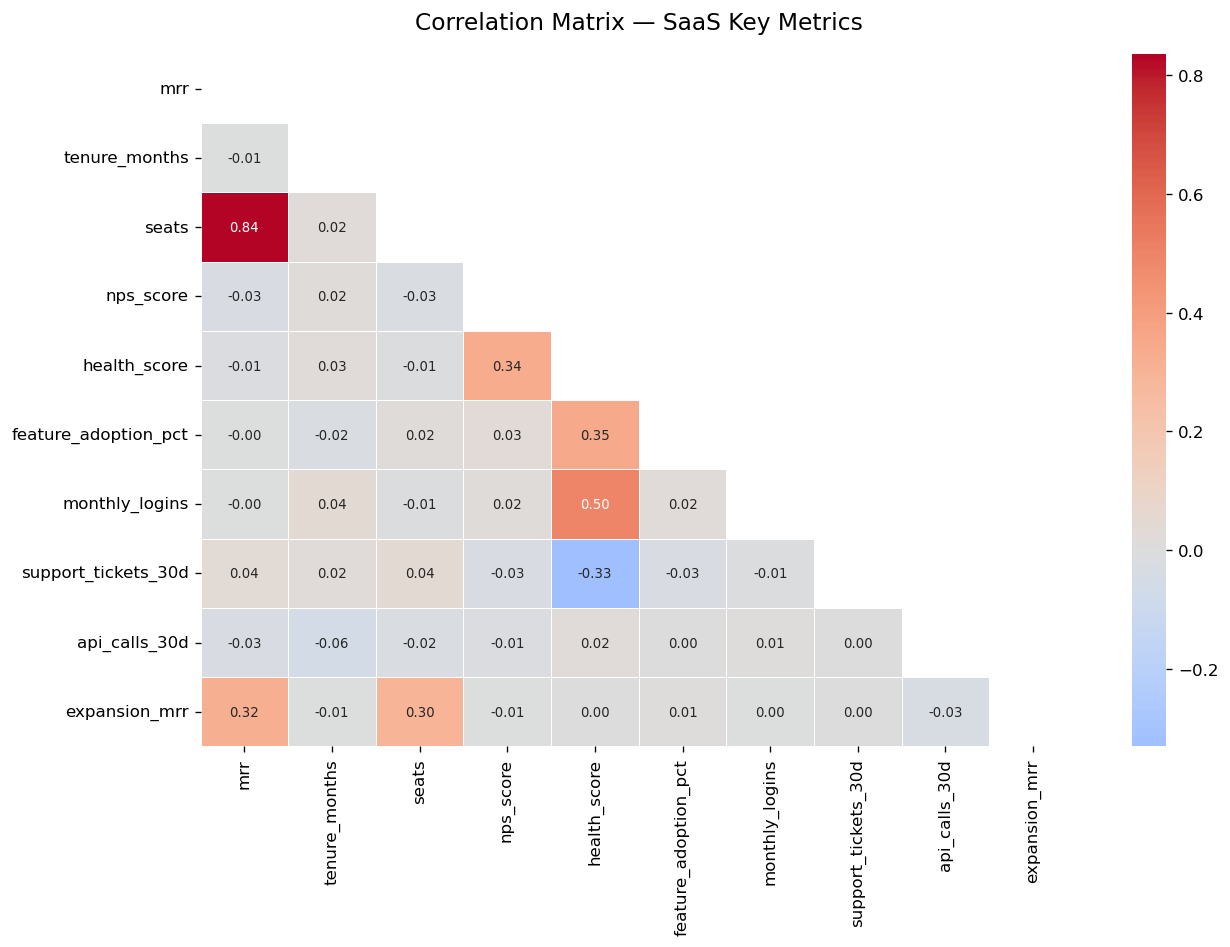

In [31]:
corr_cols = ['mrr','tenure_months','seats','nps_score','health_score',
             'feature_adoption_pct','monthly_logins','support_tickets_30d',
             'api_calls_30d','expansion_mrr']

corr_matrix = df[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — SaaS Key Metrics', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### 6.5 RFM-style Segmentation (Recency · Frequency · Monetary)

In [37]:
# R = tenure_months (longer = more loyal), F = monthly_logins, M = total_mrr
rfm = df[['customer_id','tenure_months','monthly_logins','total_mrr']].copy()

rfm['R'] = pd.qcut(rfm['tenure_months'], 4, labels=[1,2,3,4])
rfm['F'] = pd.qcut(rfm['monthly_logins'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['total_mrr'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['R'] = rfm['R'].cat.codes + 1
rfm['F'] = rfm['F'].cat.codes + 1
rfm['M'] = rfm['M'].cat.codes + 1
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(score):
    if score >= 11: return 'Champions'
    elif score >= 8: return 'Loyal'
    elif score >= 6: return 'Potential'
    elif score >= 4: return 'At Risk'
    else:            return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(rfm_segment)
df = df.merge(rfm[['customer_id','RFM_score','segment']], on='customer_id', how='left')

print("RFM Segment Distribution:")
print(rfm['segment'].value_counts())
print(f"MRR by Segment:")
df.groupby('segment')['total_mrr'].agg(['count','sum','mean'])   .sort_values('sum', ascending=False)   .style.format({'sum':'${:,.0f}','mean':'${:,.2f}'})


RFM Segment Distribution:
segment
At Risk      751
Potential    640
Loyal        292
Lost         287
Champions     30
Name: count, dtype: int64
MRR by Segment:


,count,sum,mean
segment,,,
Potential,640,"$133,949",$209.30
Loyal,292,"$89,473",$306.41
At Risk,751,"$77,746",$103.52
Champions,30,"$12,491",$416.37
Lost,287,"$2,924",$10.19


### 6.6 Rolling 3-Month Churn Rate Trend

In [38]:
monthly_churn = (
    df.groupby('signup_month')
    .agg(total=('customer_id','count'), churned=('churn','sum'))
    .assign(churn_rate=lambda x: x['churned']/x['total']*100)
    .sort_index()
)

monthly_churn['churn_rate_3m_avg'] = monthly_churn['churn_rate'].rolling(3, min_periods=1).mean()

print("Rolling 3-Month Churn Rate Trend (last 12 periods):")
monthly_churn[['total','churned','churn_rate','churn_rate_3m_avg']].tail(12)     .style.format({'churn_rate': '{:.2f}%', 'churn_rate_3m_avg': '{:.2f}%'})


Rolling 3-Month Churn Rate Trend (last 12 periods):


,total,churned,churn_rate,churn_rate_3m_avg
signup_month,,,,
2023-02,9,4,44.44%,32.97%
2023-03,9,2,22.22%,28.47%
2023-04,17,1,5.88%,24.18%
2023-05,16,2,12.50%,13.53%
2023-06,18,6,33.33%,17.24%
2023-07,11,3,27.27%,24.37%
2023-08,13,1,7.69%,22.77%
2023-09,13,3,23.08%,19.35%
2023-10,11,5,45.45%,25.41%


---
## 7. Matplotlib Visualizations <a id='7'></a>

In [40]:
# ── Color palette ─────────────────────────────────────────────────────────
COLORS = {
    'Free':       '#94a3b8',
    'Starter':    '#60a5fa',
    'Growth':     '#34d399',
    'Business':   '#f59e0b',
    'Enterprise': '#f43f5e',
}
PLAN_COLORS = [COLORS[p] for p in plan_order]


### 7.1 MRR Distribution by Plan — Box + Strip Plot

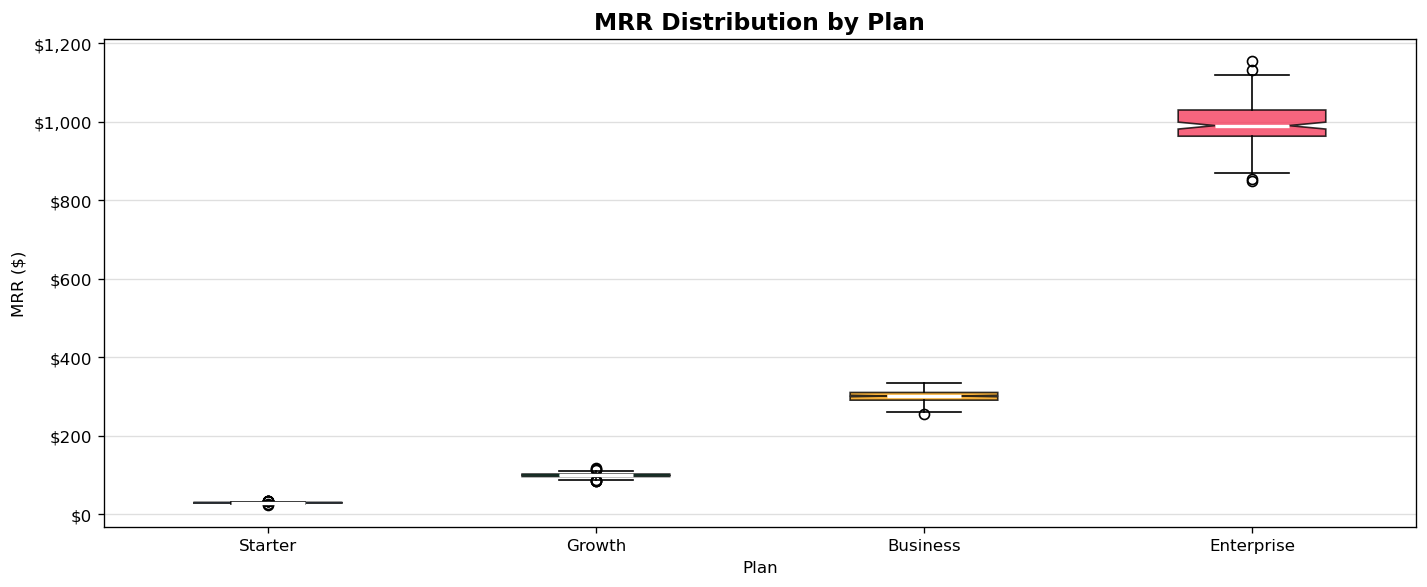

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

# Only paid plans
paid = df[df['plan'] != 'Free']
plan_data = [paid[paid['plan']==p]['mrr'].values for p in plan_order[1:]]
bp = ax.boxplot(plan_data, patch_artist=True, notch=True,
                medianprops={'color':'white','linewidth':2})

for patch, color in zip(bp['boxes'], PLAN_COLORS[1:]):
    patch.set_facecolor(color); patch.set_alpha(0.8)

ax.set_xticklabels(plan_order[1:])
ax.set_title('MRR Distribution by Plan', fontsize=14, fontweight='bold')
ax.set_xlabel('Plan'); ax.set_ylabel('MRR ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


### 7.2 Customer Count & MRR Share by Plan — Dual Bar

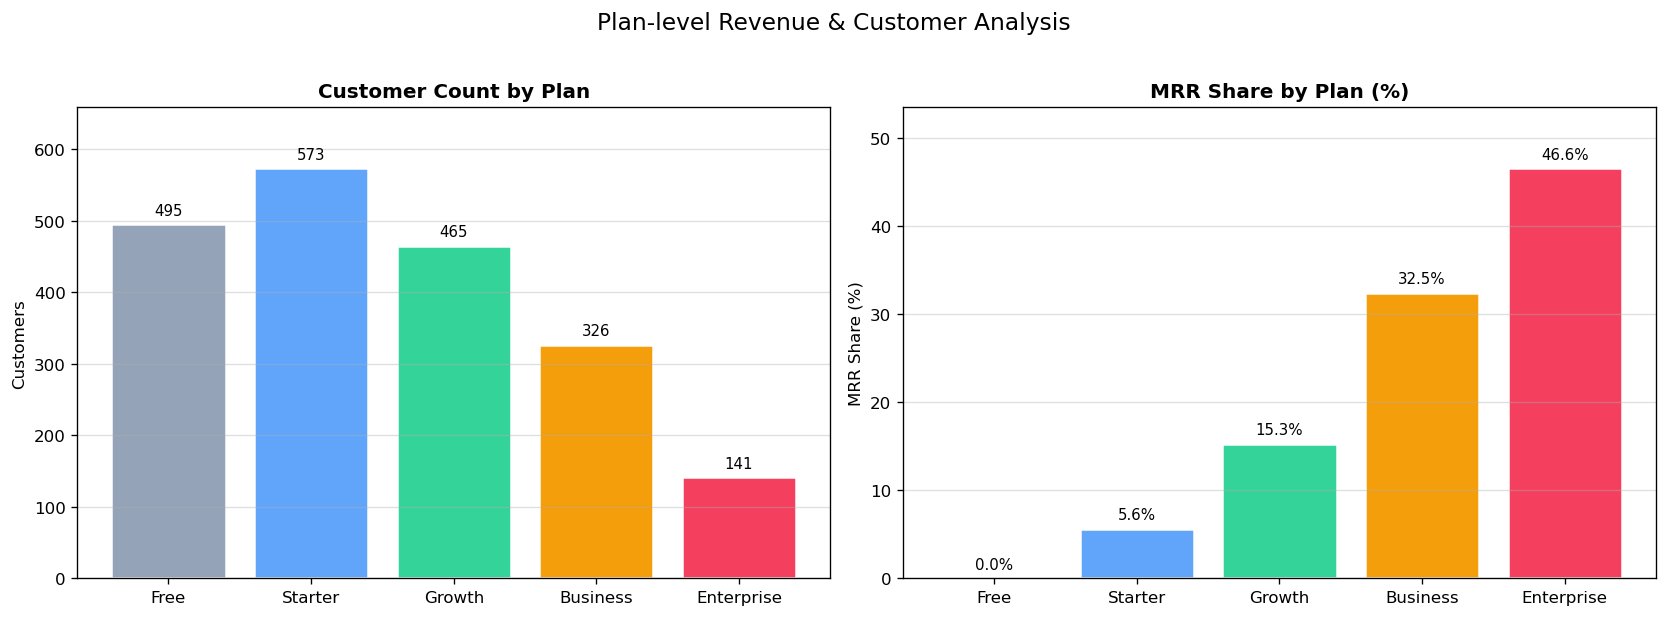

In [42]:
summary = revenue_by_plan.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count
bars1 = axes[0].bar(summary['plan'], summary['customers'], color=PLAN_COLORS, edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars1, fmt='%d', padding=4, fontsize=9)
axes[0].set_title('Customer Count by Plan', fontweight='bold')
axes[0].set_ylabel('Customers')
axes[0].set_ylim(0, summary['customers'].max() * 1.15)
axes[0].grid(axis='y', alpha=0.4)

# MRR share
bars2 = axes[1].bar(summary['plan'], summary['mrr_share_pct'], color=PLAN_COLORS, edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)
axes[1].set_title('MRR Share by Plan (%)', fontweight='bold')
axes[1].set_ylabel('MRR Share (%)')
axes[1].set_ylim(0, summary['mrr_share_pct'].max() * 1.15)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Plan-level Revenue & Customer Analysis', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


### 7.3 Churn Rate by Plan — Horizontal Bar

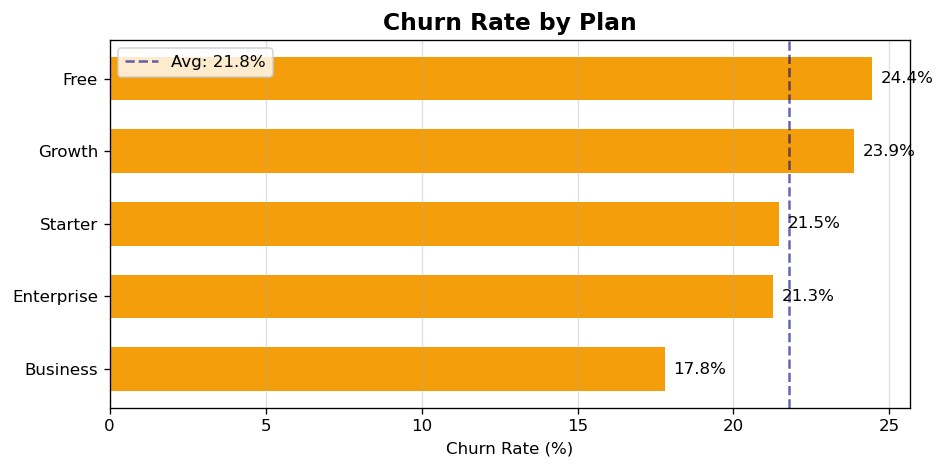

In [43]:
churn_summary = df.groupby('plan', observed=True)['churn'].mean().mul(100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#ef4444' if v > 25 else '#f59e0b' if v > 15 else '#22c55e'
          for v in churn_summary.values]
bars = ax.barh(churn_summary.index, churn_summary.values, color=colors, height=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10)
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Plan', fontsize=14, fontweight='bold')
ax.axvline(churn_summary.mean(), color='navy', linestyle='--', alpha=0.6,
           label=f'Avg: {churn_summary.mean():.1f}%')
ax.legend(); ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()


### 7.4 Monthly New MRR & Churn Trend

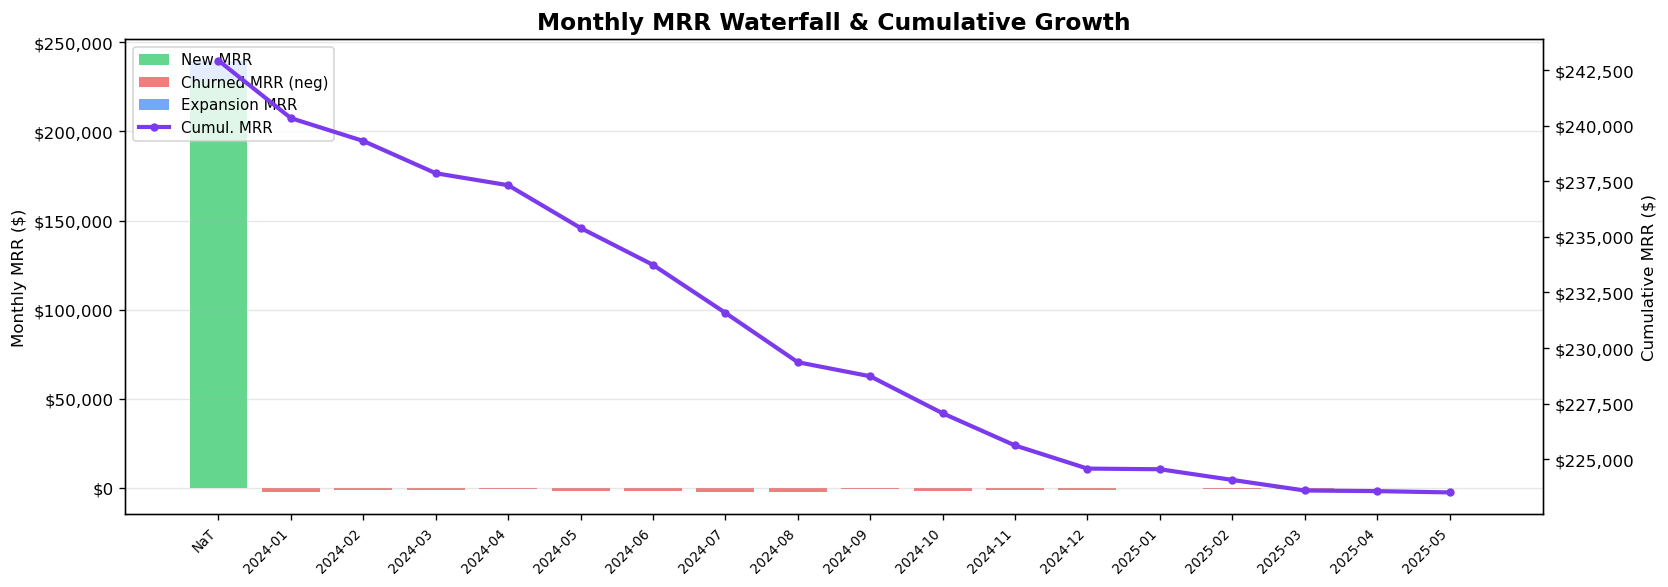

In [44]:
wf = waterfall.reset_index().rename(columns={'index': 'month'})
wf = wf.tail(18)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

x = range(len(wf))
ax1.bar(x, wf['new_mrr'], alpha=0.7, color='#22c55e', label='New MRR')
ax1.bar(x, -wf['churned_mrr'], alpha=0.7, color='#ef4444', label='Churned MRR (neg)')
ax1.bar(x, wf['expansion_mrr'], alpha=0.7, color='#3b82f6', bottom=wf['new_mrr'], label='Expansion MRR')
ax2.plot(x, wf['cumulative_mrr'], color='#7c3aed', linewidth=2.5, marker='o', markersize=4, label='Cumul. MRR')

ax1.set_xticks(x); ax1.set_xticklabels(wf['month'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Monthly MRR ($)'); ax2.set_ylabel('Cumulative MRR ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
ax1.set_title('Monthly MRR Waterfall & Cumulative Growth', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


### 7.5 Feature Adoption vs Health Score — Scatter by Plan

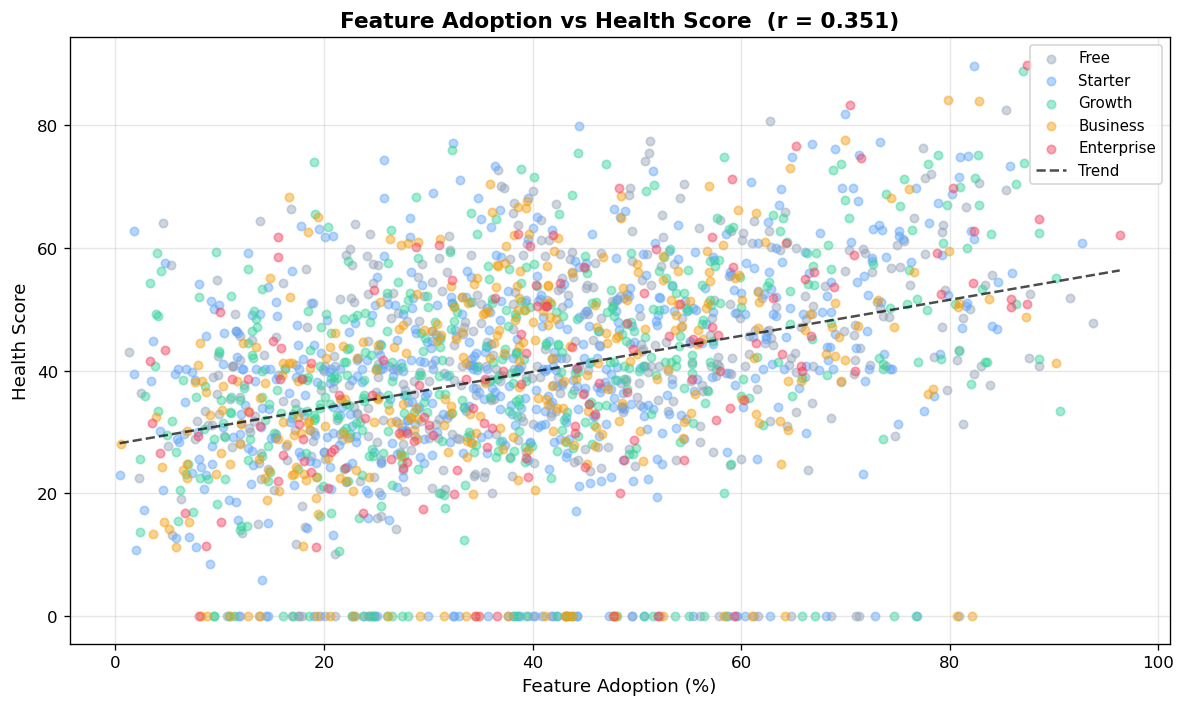

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

for plan in plan_order:
    sub = df[df['plan'] == plan]
    ax.scatter(sub['feature_adoption_pct'], sub['health_score'],
               label=plan, alpha=0.45, s=25, color=COLORS[plan])

# Regression line
from numpy.polynomial import polynomial as P
mask = df['health_score'].notna()
x, y = df.loc[mask, 'feature_adoption_pct'], df.loc[mask, 'health_score']
coefs = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coefs, x_line), 'k--', linewidth=1.5, alpha=0.7, label='Trend')

corr = np.corrcoef(x, y)[0,1]
ax.set_xlabel('Feature Adoption (%)', fontsize=11)
ax.set_ylabel('Health Score', fontsize=11)
ax.set_title(f'Feature Adoption vs Health Score  (r = {corr:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.6 NPS Distribution — KDE by Plan

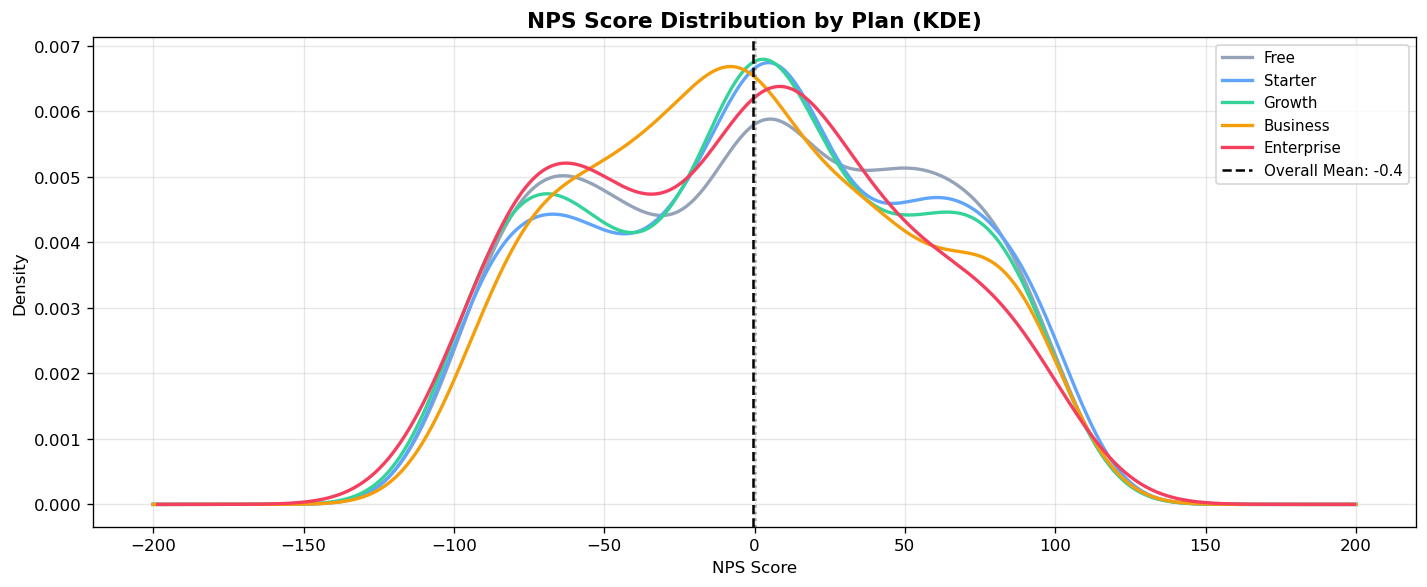

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

for plan in plan_order:
    sub = df[df['plan']==plan]['nps_score'].dropna()
    sub.plot.kde(ax=ax, label=plan, color=COLORS[plan], linewidth=2)

ax.axvline(0, color='gray', linestyle=':', alpha=0.7)
ax.axvline(df['nps_score'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Mean: {df["nps_score"].mean():.1f}')
ax.set_xlabel('NPS Score'); ax.set_ylabel('Density')
ax.set_title('NPS Score Distribution by Plan (KDE)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.7 Cohort Heatmap — Monthly Retention

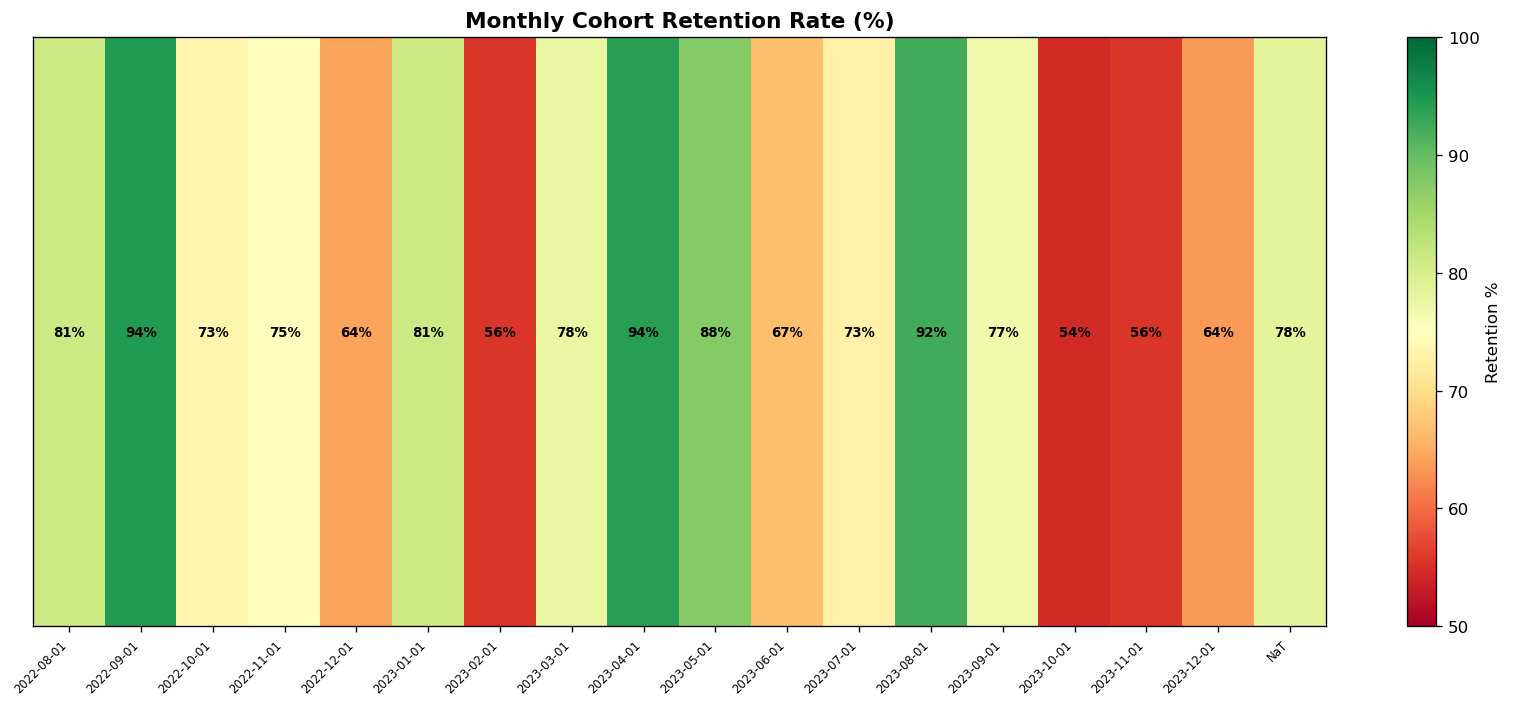

In [47]:
cohort_pivot = cohort_data[['retention_rate']].copy()
cohort_pivot.index = pd.to_datetime(cohort_pivot.index)
cohort_pivot = cohort_pivot.sort_index().tail(18)

fig, ax = plt.subplots(figsize=(14, 6))
vals = cohort_pivot['retention_rate'].values.reshape(-1, 1)
im = ax.imshow(vals.T, aspect='auto', cmap='RdYlGn', vmin=50, vmax=100)

ax.set_xticks(range(len(cohort_pivot)))
ax.set_xticklabels([str(d.date()) for d in cohort_pivot.index], rotation=45, ha='right', fontsize=7)
ax.set_yticks([])
ax.set_title('Monthly Cohort Retention Rate (%)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Retention %')

for i, v in enumerate(cohort_pivot['retention_rate'].values):
    ax.text(i, 0, f'{v:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold')

plt.tight_layout(); plt.show()


---
## 8. Plotly Interactive Dashboard <a id='8'></a>

In [48]:
import plotly.io as pio
# Auto-detect best renderer for Jupyter
import sys
if 'ipykernel' in sys.modules:
    pio.renderers.default = 'iframe'
else:
    pio.renderers.default = 'browser'
print('Plotly renderer:', pio.renderers.default)


Plotly renderer: iframe


### 8.1 KPI Summary Cards

In [49]:
total_customers = len(df)
active_customers = df[df['churn']==False].shape[0]
total_mrr_val = df[df['churn']==False]['total_mrr'].sum()
overall_churn = df['churn'].mean() * 100
avg_ltv = df['estimated_ltv'].median()
avg_health = df['health_score'].mean()

fig = go.Figure()

kpis = [
    ('Total Customers',   f'{total_customers:,}',    '#3b82f6'),
    ('Active Customers',  f'{active_customers:,}',   '#22c55e'),
    ('Total MRR',         f'${total_mrr_val:,.0f}',  '#8b5cf6'),
    ('Churn Rate',        f'{overall_churn:.1f}%',   '#ef4444'),
    ('Median LTV',        f'${avg_ltv:,.0f}',        '#f59e0b'),
    ('Avg Health Score',  f'{avg_health:.1f}',       '#06b6d4'),
]

# Use subplots layout for reliable KPI card rendering
from plotly.subplots import make_subplots as _msp
fig = _msp(rows=1, cols=6, specs=[[{'type':'indicator'}]*6])

for i, (label, value, color) in enumerate(kpis):
    num_str = value.replace('$','').replace(',','').replace('%','')
    fig.add_trace(go.Indicator(
        mode='number',
        value=float(num_str),
        title={'text': f'<b>{label}</b>', 'font': {'size': 12, 'color': '#64748b'}},
        number={
            'prefix': '$' if '$' in value else '',
            'suffix': '%' if '%' in value else '',
            'font': {'size': 26, 'color': color},
            'valueformat': ',.0f' if '$' in value or value.replace(',','').isdigit() else '.1f',
        },
    ), row=1, col=i+1)

fig.update_layout(
    height=180,
    title={'text': '📊 SaaS Business KPI Dashboard', 'x': 0.5, 'font': {'size': 16}},
    margin={'t': 70, 'b': 10, 'l': 20, 'r': 20},
    paper_bgcolor='#f8fafc',
    plot_bgcolor='#f8fafc',
)
fig.show()


### 8.2 Interactive MRR Waterfall Chart

In [50]:
wf_plot = waterfall.copy()
wf_plot.index = wf_plot.index.astype(str)
wf_plot = wf_plot.tail(18).reset_index().rename(columns={'index':'month'})

colors_waterfall = ['green' if v >= 0 else 'red' for v in wf_plot['net_new_mrr']]

fig = go.Figure()

fig.add_trace(go.Bar(name='New MRR', x=wf_plot['month'], y=wf_plot['new_mrr'],
                     marker_color='#22c55e', opacity=0.85))
fig.add_trace(go.Bar(name='Expansion MRR', x=wf_plot['month'], y=wf_plot['expansion_mrr'],
                     marker_color='#3b82f6', opacity=0.85))
fig.add_trace(go.Bar(name='Churned MRR', x=wf_plot['month'], y=-wf_plot['churned_mrr'],
                     marker_color='#ef4444', opacity=0.85))
fig.add_trace(go.Scatter(name='Cumulative MRR', x=wf_plot['month'],
                          y=wf_plot['cumulative_mrr'], mode='lines+markers',
                          line={'color':'#7c3aed','width':2.5},
                          yaxis='y2'))

fig.update_layout(
    title='Monthly MRR Waterfall — New / Expansion / Churned',
    barmode='overlay',
    xaxis_tickangle=-45,
    yaxis={'title': 'Monthly MRR ($)', 'tickprefix': '$'},
    yaxis2={'title': 'Cumulative MRR ($)', 'overlaying': 'y', 'side': 'right', 'tickprefix': '$'},
    legend={'orientation': 'h', 'y': 1.1},
    height=480,
    template='plotly_white'
)
fig.show()


### 8.3 Churn Rate Heatmap — Region × Plan

In [51]:
churn_heat = df.groupby(['region','plan'], observed=True)['churn']                .mean().mul(100).round(1).reset_index()
churn_heat.columns = ['region','plan','churn_rate']

pivot_heat = churn_heat.pivot(index='region', columns='plan', values='churn_rate')

fig = px.imshow(
    pivot_heat,
    color_continuous_scale='RdYlGn_r',
    text_auto='.1f',
    title='Churn Rate (%) Heatmap — Region × Plan',
    labels={'color': 'Churn Rate (%)'},
    aspect='auto',
    height=380,
)
fig.update_layout(template='plotly_white')
fig.show()


### 8.4 Treemap — MRR by Region > Industry > Plan

In [52]:
treemap_df = (
    df[df['churn']==False]
    .groupby(['region','industry','plan'], observed=True)['total_mrr']
    .sum().reset_index()
)

# Filter out zero-MRR rows to avoid ZeroDivisionError in plotly treemap
treemap_df = treemap_df[treemap_df['total_mrr'] > 0].copy()

fig = px.treemap(
    treemap_df,
    path=['region', 'industry', 'plan'],
    values='total_mrr',
    title='Active MRR — Region › Industry › Plan Breakdown',
    height=550,
    color_discrete_sequence=px.colors.qualitative.Set3,
)
fig.update_traces(textinfo='label+value+percent parent',
                  marker={'line': {'width': 1, 'color': 'white'}})
fig.update_layout(template='plotly_white')
fig.show()


### 8.5 Scatter — Health Score vs MRR (interactive)

In [53]:
scatter_df = df[df['churn']==False].sample(600, random_state=42)

scatter_df = scatter_df.copy()
scatter_df['plan'] = scatter_df['plan'].astype(str)
fig = px.scatter(
    scatter_df,
    x='health_score', y='total_mrr',
    color='plan', size='seats',
    hover_data=['customer_id','industry','region','tenure_months','nps_score'],
    color_discrete_map=COLORS,
    title='Health Score vs MRR — Active Customers (bubble size = seats)',
    labels={'health_score': 'Health Score', 'total_mrr': 'Total MRR ($)'},
    height=520,
    template='plotly_white',
    opacity=0.75,
)
fig.update_traces(marker={'line': {'width': 0.5, 'color': 'white'}})
fig.show()


### 8.6 Funnel — Customer Journey by Plan (Active)

In [54]:
funnel_data = df[df['churn']==False].groupby('plan', observed=True).size().reset_index(name='count')

fig = go.Figure(go.Funnel(
    y=funnel_data['plan'].tolist(),
    x=funnel_data['count'].tolist(),
    textinfo='value+percent initial+percent previous',
    marker={'color': PLAN_COLORS},
))
fig.update_layout(
    title='Active Customer Conversion Funnel by Plan',
    height=420,
    template='plotly_white'
)
fig.show()


### 8.7 Time Series — Signups by Month & Plan (Area Chart)

In [55]:
signup_ts = (
    df.assign(signup_month_str=df['signup_month'].astype(str))
    .groupby(['signup_month_str','plan'], observed=True)
    .size().reset_index(name='signups')
    .rename(columns={'signup_month_str':'signup_month'})
    .sort_values('signup_month')
)

fig = px.area(
    signup_ts,
    x='signup_month', y='signups', color='plan',
    color_discrete_map=COLORS,
    title='Monthly Signups by Plan',
    labels={'signup_month': 'Month', 'signups': 'New Signups'},
    height=430,
    template='plotly_white',
)
fig.update_layout(xaxis_tickangle=-45, legend={'orientation':'h','y':1.1})
fig.show()


### 8.8 RFM Segment Bubble Chart

In [56]:
rfm_summary = (
    df.groupby('segment')
    .agg(customers=('customer_id','count'),
         avg_mrr=('total_mrr','mean'),
         avg_health=('health_score','mean'),
         churn_rate=('churn','mean'))
    .reset_index()
    .assign(churn_rate=lambda x: x['churn_rate']*100)
)

fig = px.scatter(
    rfm_summary,
    x='avg_health', y='avg_mrr',
    size='customers', color='churn_rate',
    text='segment',
    color_continuous_scale='RdYlGn_r',
    title='RFM Segments — Health vs MRR (size=customers, color=churn rate)',
    labels={'avg_health':'Avg Health Score','avg_mrr':'Avg MRR ($)','churn_rate':'Churn Rate (%)'},
    height=480,
    template='plotly_white',
    size_max=60,
)
fig.update_traces(textposition='top center', marker={'line':{'width':1,'color':'white'}})
fig.show()


### 8.9 Full Multi-Panel Dashboard

In [57]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'MRR by Plan', 'Churn Rate by Plan',
        'Customers by Region', 'Acquisition Channel MRR',
        'Contract Type Mix', 'Engagement Tier Distribution'
    ],
    specs=[[{'type':'bar'},{'type':'bar'},{'type':'pie'}],
           [{'type':'bar'},{'type':'pie'},{'type':'bar'}]]
)

# ① MRR by Plan
mrr_plan = df[df['churn']==False].groupby('plan',observed=True)['total_mrr'].sum().reset_index()
mrr_plan['plan'] = mrr_plan['plan'].astype(str)
fig.add_trace(go.Bar(x=mrr_plan['plan'], y=mrr_plan['total_mrr'],
    marker_color=PLAN_COLORS, showlegend=False), row=1, col=1)

# ② Churn by Plan
churn_plan = df.groupby('plan',observed=True)['churn'].apply(lambda x: x.astype(int).mean()).mul(100).reset_index()
churn_plan.columns = ['plan','churn_rate']
fig.add_trace(go.Bar(x=churn_plan['plan'], y=churn_plan['churn_rate'],
    marker_color=PLAN_COLORS, showlegend=False), row=1, col=2)

# ③ Customers by Region (Pie)
reg_counts = df.groupby('region').size().reset_index(name='count')
fig.add_trace(go.Pie(labels=reg_counts['region'], values=reg_counts['count'],
    hole=0.4, showlegend=False), row=1, col=3)

# ④ Acquisition Channel MRR
ch_mrr = (df[df['acquisition_channel']!='Unknown']
          .groupby('acquisition_channel')['total_mrr'].sum()
          .sort_values(ascending=True).reset_index())
fig.add_trace(go.Bar(x=ch_mrr['total_mrr'], y=ch_mrr['acquisition_channel'],
    orientation='h', marker_color='#3b82f6', showlegend=False), row=2, col=1)

# ⑤ Contract Type (Pie)
ct = df.groupby('contract_type').size().reset_index(name='count')
fig.add_trace(go.Pie(labels=ct['contract_type'], values=ct['count'],
    hole=0.4, showlegend=False), row=2, col=2)

# ⑥ Engagement Tier
eng = df.groupby('engagement_tier', observed=True).size().reset_index(name='count')
fig.add_trace(go.Bar(x=eng['engagement_tier'], y=eng['count'],
    marker_color=['#94a3b8','#60a5fa','#34d399','#f59e0b'], showlegend=False), row=2, col=3)

fig.update_layout(
    height=650,
    title_text='🏢 SaaS Business Intelligence — Full Dashboard',
    title_x=0.5, title_font_size=16,
    template='plotly_white',
)
fig.show()


---
## 9. Key Business Insights Summary <a id='9'></a>

In [58]:
print("=" * 60)
print("  📈 SaaS PORTFOLIO PROJECT — KEY BUSINESS INSIGHTS")
print("=" * 60)

active = df[df['churn']==False]

lines = [
    "\nREVENUE SNAPSHOT",
    f"  Total Active MRR         : ${active['total_mrr'].sum():>12,.0f}",
    f"  Total ARR                : ${active['arr'].sum():>12,.0f}",
    f"  Avg MRR per Customer     : ${active['total_mrr'].mean():>12,.2f}",
    f"  Expansion MRR Total      : ${active['expansion_mrr'].sum():>12,.0f}",
    "\nCUSTOMER METRICS",
    f"  Total Customers          : {len(df):>12,}",
    f"  Active Customers         : {len(active):>12,}",
    f"  Churned Customers        : {df['churn'].sum():>12,}",
    f"  Overall Churn Rate       : {df['churn'].mean()*100:>11.1f}%",
    "\nENGAGEMENT",
    f"  Avg Health Score         : {df['health_score'].mean():>12.1f}",
    f"  Avg Feature Adoption     : {df['feature_adoption_pct'].mean():>11.1f}%",
    f"  Avg Monthly Logins       : {df['monthly_logins'].mean():>12.1f}",
    f"  Avg NPS Score            : {df['nps_score'].mean():>12.1f}",
    "\nTOP INSIGHTS",
    f"  Top Plan by MRR  : {active.groupby('plan', observed=True)['total_mrr'].sum().idxmax()}",
    f"  Top Region       : {active.groupby('region')['total_mrr'].sum().idxmax()}",
    f"  Top Industry     : {active.groupby('industry')['total_mrr'].sum().idxmax()}",
    f"  Top Channel      : {active[active['acquisition_channel']!='Unknown'].groupby('acquisition_channel')['total_mrr'].sum().idxmax()}",
]
print("\n".join(lines))
print("=" * 60)


  📈 SaaS PORTFOLIO PROJECT — KEY BUSINESS INSIGHTS

REVENUE SNAPSHOT
  Total Active MRR         : $     254,819
  Total ARR                : $   3,057,834
  Avg MRR per Customer     : $      163.66
  Expansion MRR Total      : $      15,554

CUSTOMER METRICS
  Total Customers          :        2,000
  Active Customers         :        1,557
  Churned Customers        :          443
  Overall Churn Rate       :        22.1%

ENGAGEMENT
  Avg Health Score         :         39.7
  Avg Feature Adoption     :        39.8%
  Avg Monthly Logins       :         10.8
  Avg NPS Score            :         -0.4

TOP INSIGHTS
  Top Plan by MRR  : Enterprise
  Top Region       : North America
  Top Industry     : Hr Tech
  Top Channel      : Organic Search


---
## 🎓 Pandas Skills Demonstrated in This Notebook

| Category | Skills |
|---|---|
| **Loading & Basics** | `read_csv`, `head/tail`, `info`, `describe`, `dtypes`, `shape` |
| **Selection** | `loc`, `iloc`, boolean indexing, `.query()` |
| **Cleaning** | `drop_duplicates`, `str.strip`, `str.title`, `str.replace`, `fillna`, `astype` |
| **Dates** | `pd.to_datetime` with mixed formats, `.dt.days`, `.dt.to_period`, `.dt.month` |
| **Categoricals** | `pd.Categorical` ordered, `pd.cut`, `pd.qcut` |
| **Groupby** | Single/multi-key groupby, `agg` with named aggregations, `transform` |
| **Pivot** | `pivot_table`, multi-index groupby |
| **Merge/Join** | `merge` on key column |
| **Apply** | Row-wise `apply` with lambda and named functions |
| **Window** | `rolling().mean()` for trend smoothing |
| **Feature Eng.** | Derived columns, ratios, ranking with `.rank()` |
| **Advanced** | RFM segmentation, cohort retention, MRR waterfall, LTV model, correlation matrix |
| **Styling** | `.style.format`, `.background_gradient`, `.highlight_max/min`, `.bar` |
| **Visualization** | Matplotlib subplots, seaborn heatmap, Plotly express & graph objects, dashboards |
